# Model Evaluation on Test Data
This notebook evaluates all 4 trained models on the held-out test set.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, precision_score,
    recall_score, roc_curve, roc_auc_score, accuracy_score
)

In [47]:
x_test = pd.read_csv('/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Data/x_test.csv')
y_test = pd.read_csv('/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Data/y_test.csv').squeeze()

In [48]:
# Funcs 
def log_transform(x):
    return np.log1p(x)

def to_str_func(x):
    return x.astype(str)

---
## 1. Logistic Regression (Base Model)

In [49]:
lr_model = joblib.load('/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Models/lr_model.pkl')

y_test_pred = lr_model.predict(x_test)

print(precision_score(y_test, y_test_pred, pos_label=1) * 100)
print(recall_score(y_test, y_test_pred, pos_label=1) * 100)

70.13801756587202
78.51123595505618


In [50]:
f1_score(y_test, y_test_pred) * 100

74.08880053015243

In [51]:
acc = accuracy_score(y_test, y_test_pred)
print(acc)

0.7884199134199135


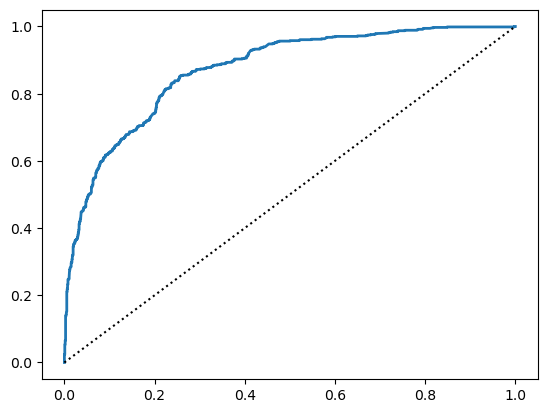

In [16]:
y_scores = lr_model.decision_function(x_test)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
plt.plot(fpr, tpr, linewidth=2, label="Roc curve")
plt.plot([0,1],[0,1],'k:', label="Random classifier's ROC curve")
plt.show()

In [52]:
roc_auc_score(y_test, y_scores)

np.float64(0.9041599491612597)

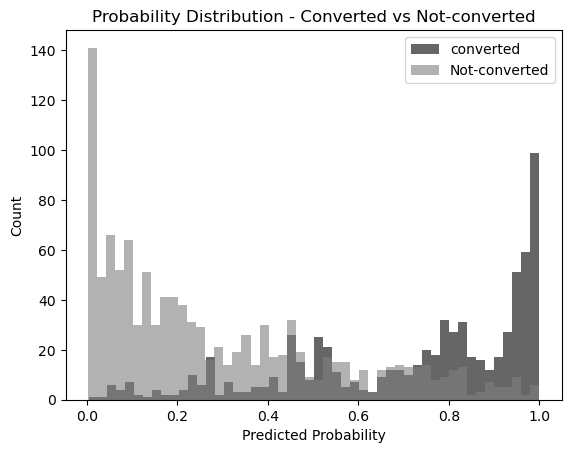

In [18]:
coversion_probs = lr_model.predict_proba(x_test)[y_test == 1, 1]
non_coversion_probs = lr_model.predict_proba(x_test)[y_test == 0, 1]

plt.hist(coversion_probs, bins=50, alpha=0.6, label='converted', color='black')
plt.hist(non_coversion_probs, bins=50, alpha=0.6, label='Not-converted', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Converted vs Not-converted')
plt.legend()
plt.show()

In [53]:
print(f"conversion Mean:      {coversion_probs.mean():.4f}")
print(f"Non-conversion Mean:  {non_coversion_probs.mean():.4f}")
print(f"Gap:             {(coversion_probs.mean() - non_coversion_probs.mean()):.4f}")
print(f"conversion Max:       {coversion_probs.max():.4f}")
print(f"Non conversion max: {non_coversion_probs.max():.4f}")
print(f"conversion Std:         {coversion_probs.std():.4f}")
print(f"Non-conversion Std:     {non_coversion_probs.std():.4f}")

conversion Mean:      0.7296
Non-conversion Mean:  0.2215
Gap:             0.5081
conversion Max:       0.9994
Non conversion max: 0.9923
conversion Std:         0.2649
Non-conversion Std:     0.2441


---
## 2. Random Forest

In [54]:
rf_model = joblib.load('/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Models/rf_model.pkl')

y_test_pred = rf_model.predict(x_test)

print(precision_score(y_test, y_test_pred, pos_label=1) * 100)
print(recall_score(y_test, y_test_pred, pos_label=1) * 100)

74.01360544217687
76.40449438202246


In [55]:
f1_score(y_test, y_test_pred) * 100

75.19004837595024

In [56]:
acc = accuracy_score(y_test, y_test_pred)
print(acc)

0.8057359307359307


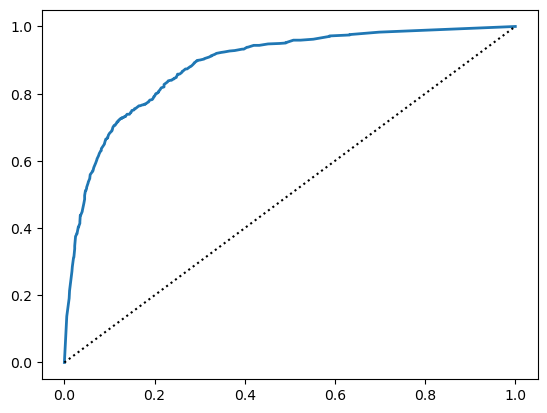

In [23]:
y_scores = rf_model.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
plt.plot(fpr, tpr, linewidth=2, label="Roc curve")
plt.plot([0,1],[0,1],'k:', label="Random classifier's ROC curve")
plt.show()

In [57]:
roc_auc_score(y_test, y_scores)

np.float64(0.9041599491612597)

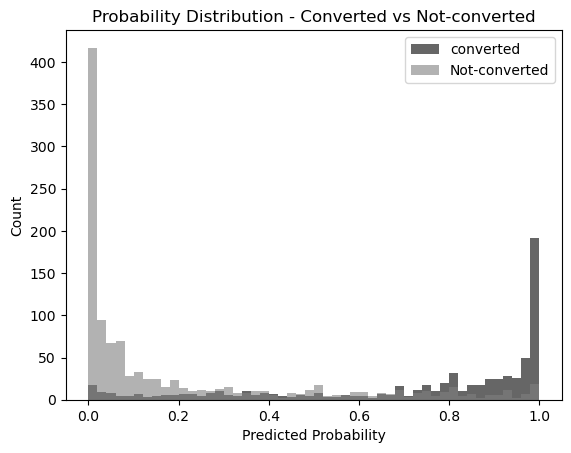

In [25]:
coversion_probs = rf_model.predict_proba(x_test)[y_test == 1, 1]
non_coversion_probs = rf_model.predict_proba(x_test)[y_test == 0, 1]

plt.hist(coversion_probs, bins=50, alpha=0.6, label='converted', color='black')
plt.hist(non_coversion_probs, bins=50, alpha=0.6, label='Not-converted', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Converted vs Not-converted')
plt.legend()
plt.show()

In [58]:
print(f"conversion Mean:      {coversion_probs.mean():.4f}")
print(f"Non-conversion Mean:  {non_coversion_probs.mean():.4f}")
print(f"Gap:             {(coversion_probs.mean() - non_coversion_probs.mean()):.4f}")
print(f"conversion Max:       {coversion_probs.max():.4f}")
print(f"Non conversion max: {non_coversion_probs.max():.4f}")
print(f"conversion Std:         {coversion_probs.std():.4f}")
print(f"Non-conversion Std:     {non_coversion_probs.std():.4f}")

conversion Mean:      0.7296
Non-conversion Mean:  0.2215
Gap:             0.5081
conversion Max:       0.9994
Non conversion max: 0.9923
conversion Std:         0.2649
Non-conversion Std:     0.2441


---
## 3. XGBoost

In [59]:
xgb_model = joblib.load('/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Models/xgb_model.pkl')

y_test_pred = xgb_model.predict(x_test)

print(precision_score(y_test, y_test_pred, pos_label=1) * 100)
print(recall_score(y_test, y_test_pred, pos_label=1) * 100)

77.20994475138122
78.51123595505618


In [60]:
f1_score(y_test, y_test_pred) * 100

77.85515320334262

In [61]:
acc = accuracy_score(y_test, y_test_pred)
print(acc)

0.827922077922078


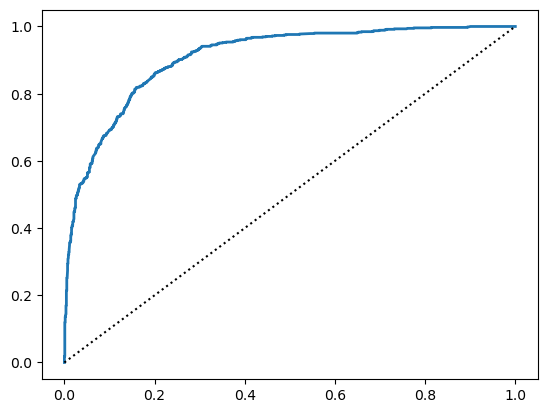

In [30]:
y_scores = xgb_model.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
plt.plot(fpr, tpr, linewidth=2, label="Roc curve")
plt.plot([0,1],[0,1],'k:', label="Random classifier's ROC curve")
plt.show()

In [62]:
roc_auc_score(y_test, y_scores)

np.float64(0.9041599491612597)

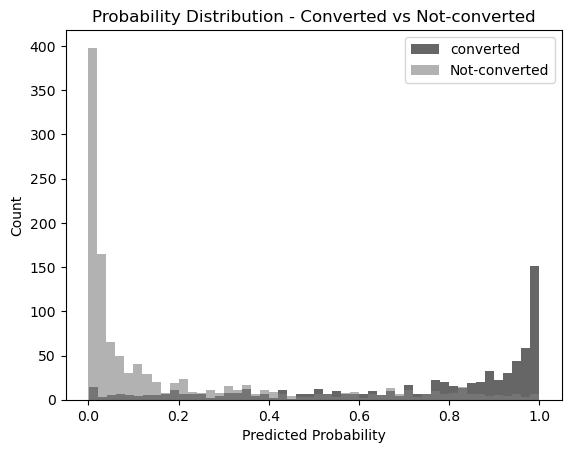

In [32]:
coversion_probs = xgb_model.predict_proba(x_test)[y_test == 1, 1]
non_coversion_probs = xgb_model.predict_proba(x_test)[y_test == 0, 1]

plt.hist(coversion_probs, bins=50, alpha=0.6, label='converted', color='black')
plt.hist(non_coversion_probs, bins=50, alpha=0.6, label='Not-converted', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Converted vs Not-converted')
plt.legend()
plt.show()

In [63]:
print(f"conversion Mean:      {coversion_probs.mean():.4f}")
print(f"Non-conversion Mean:  {non_coversion_probs.mean():.4f}")
print(f"Gap:             {(coversion_probs.mean() - non_coversion_probs.mean()):.4f}")
print(f"conversion Max:       {coversion_probs.max():.4f}")
print(f"Non conversion max: {non_coversion_probs.max():.4f}")
print(f"conversion Std:         {coversion_probs.std():.4f}")
print(f"Non-conversion Std:     {non_coversion_probs.std():.4f}")

conversion Mean:      0.7296
Non-conversion Mean:  0.2215
Gap:             0.5081
conversion Max:       0.9994
Non conversion max: 0.9923
conversion Std:         0.2649
Non-conversion Std:     0.2441


---
## 4. Ensemble (Voting Classifier: LR + RF + XGBoost)

In [64]:
import pandas as pd
import joblib
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder

# load test data
x_test = pd.read_csv('/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Data/x_test.csv')
y_test = pd.read_csv('/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Data/y_test.csv')

# load models
lr_model = joblib.load('/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Models/lr_model.pkl')
rf_model = joblib.load('/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Models/rf_model.pkl')
xgb_model = joblib.load('/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Models/xgb_model.pkl')

# build ensemble
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft'
)

ensemble_model.estimators_ = [lr_model, rf_model, xgb_model]
ensemble_model.classes_ = lr_model.classes_

ensemble_model.le_ = LabelEncoder()
ensemble_model.le_.classes_ = lr_model.classes_

# predict
y_test_pred = ensemble_model.predict(x_test)

# metrics
print(precision_score(y_test, y_test_pred, pos_label=1) * 100)
print(recall_score(y_test, y_test_pred, pos_label=1) * 100)

74.62887989203779
77.6685393258427


In [65]:
f1_score(y_test, y_test_pred) * 100

76.11837577426014

In [66]:
acc = accuracy_score(y_test, y_test_pred)
print(acc)

0.8122294372294372


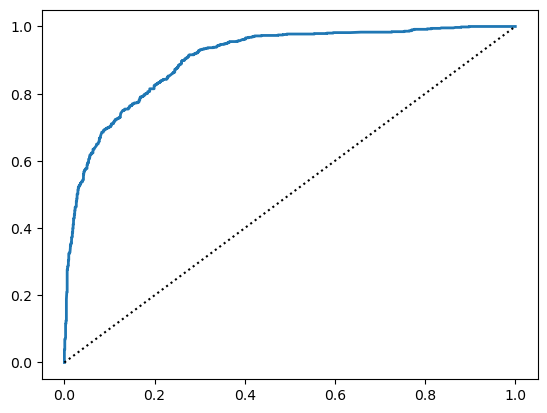

In [40]:
y_scores = ensemble_model.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
plt.plot(fpr, tpr, linewidth=2, label="Roc curve")
plt.plot([0,1],[0,1],'k:', label="Random classifier's ROC curve")
plt.show()

In [67]:
roc_auc_score(y_test, y_scores)

np.float64(0.9041599491612597)

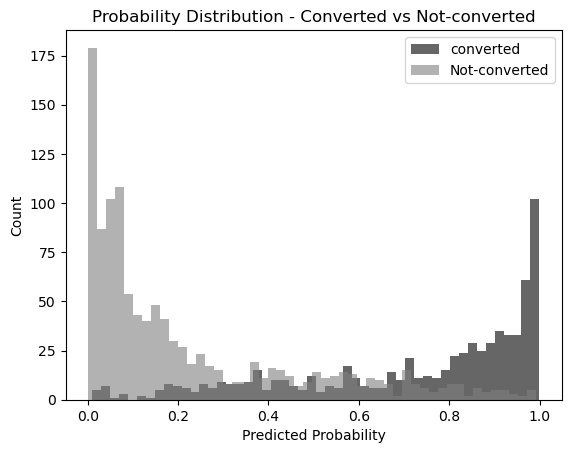

In [44]:
y_test = y_test.values.ravel()
coversion_probs = ensemble_model.predict_proba(x_test)[y_test == 1, 1]
non_coversion_probs = ensemble_model.predict_proba(x_test)[y_test == 0, 1]

plt.hist(coversion_probs, bins=50, alpha=0.6, label='converted', color='black')
plt.hist(non_coversion_probs, bins=50, alpha=0.6, label='Not-converted', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Converted vs Not-converted')
plt.legend()
plt.show()

In [68]:
print(f"conversion Mean:      {coversion_probs.mean():.4f}")
print(f"Non-conversion Mean:  {non_coversion_probs.mean():.4f}")
print(f"Gap:             {(coversion_probs.mean() - non_coversion_probs.mean()):.4f}")
print(f"conversion Max:       {coversion_probs.max():.4f}")
print(f"Non conversion max: {non_coversion_probs.max():.4f}")
print(f"conversion Std:         {coversion_probs.std():.4f}")
print(f"Non-conversion Std:     {non_coversion_probs.std():.4f}")

conversion Mean:      0.7296
Non-conversion Mean:  0.2215
Gap:             0.5081
conversion Max:       0.9994
Non conversion max: 0.9923
conversion Std:         0.2649
Non-conversion Std:     0.2441


## Model Comparison & Takeaways

- **Best Model**: XGBoost (F1: 77.86%, Accuracy: 82.79%, Precision: 77.21%, Recall: 78.51%)
- **Key Metrics**: All models achieve ROC AUC ~0.90, indicating good discrimination
- **Performance Ranking**: XGBoost > Ensemble > Random Forest > Logistic Regression
- **Insights**: XGBoost balances precision and recall best; Ensemble offers robustness but lower peak performance; Probability distributions show clear separation between converted/non-converted leads